# CIFAR-10 Benchmark

Discover, select, and compare experiment runs using the results API.

**Cell 1**: Paths setup.

**Cell 2**: Discover available runs.

**Cell 3**: Select runs for analysis.

**Cells 4+**: Plots and analysis on the selected runs.

In [1]:
from pathlib import Path

from cifar10.results import discover_runs, filter_runs, get_runs, print_run_table, load_metrics

# Root directory
ROOT = Path.cwd().parent
RUNS_DIR = ROOT / ".runs"

# Figures will be saved here for use in documentation
FIGURES_DIR = ROOT / "docs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Discover all available runs
all_runs = discover_runs(RUNS_DIR)
print(f"Found {len(all_runs)} runs in {RUNS_DIR}")
print_run_table(all_runs)

Found 7 runs in /Users/esteban/src/cifar10/.runs
Name                      Src    Arch            Params                         Best Acc   Epochs   CKPT  
----------------------------------------------------------------------------------------------------------
own_deit                  own    deit            opt=adamw                      93.15%     300      ✓     
own_vgg                   own    vgg             lr=0.05, bs=128, ep=200        96.38%     200      ✓     
own_vit                   own    vit             opt=adamw                      89.55%     300      ✓     
own_wrn                   own    wrn             lr=0.1, opt=sgd, ep=200        96.59%     300      ✓     
timm_resnet               timm   resnet          lr=0.001, opt=adamw, bs=128, ep=300 97.30%     150      ✓     
tv_convnext               tv     convnext        lr=0.001, bs=128, ep=300       99.03%     183      ✓     
tv_efficientnetv2         tv     efficientnetv2  lr=0.0625, bs=128, ep=300      98.68%    

In [2]:
# ---------------------------------------------------------------------------
# Select runs for analysis
# ---------------------------------------------------------------------------

# Option A: Filter by criteria
# selected = filter_runs(all_runs, source="own")
# selected = filter_runs(all_runs, architecture="vgg")
# selected = filter_runs(all_runs, pretrained=True)

# Option B: Manual list of run names
selected = get_runs([
    "own_wrn",
    "own_vgg",
    "own_vit",
    "own_deit",
    "own_resnet",
    "own_efficientnetv2",
    "tv_convnext",
    "tv_efficientnetv2",
    "timm_resnet"
], root=RUNS_DIR)

# Option C: All runs
# selected = all_runs

print(f"Selected {len(selected)} runs for analysis:")
print_run_table(selected)

Selected 7 runs for analysis:
Name                      Src    Arch            Params                         Best Acc   Epochs   CKPT  
----------------------------------------------------------------------------------------------------------
own_wrn                   own    wrn             lr=0.1, opt=sgd, ep=200        96.59%     300      ✓     
own_vgg                   own    vgg             lr=0.05, bs=128, ep=200        96.38%     200      ✓     
own_vit                   own    vit             opt=adamw                      89.55%     300      ✓     
own_deit                  own    deit            opt=adamw                      93.15%     300      ✓     
tv_convnext               tv     convnext        lr=0.001, bs=128, ep=300       99.03%     183      ✓     
tv_efficientnetv2         tv     efficientnetv2  lr=0.0625, bs=128, ep=300      98.68%     235      ✓     
timm_resnet               timm   resnet          lr=0.001, opt=adamw, bs=128, ep=300 97.30%     150      ✓     


In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

# Plot style
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "figure.figsize": (10, 5),
})


def save_figure(fig, filename: str):
    """Save a matplotlib figure to FIGURES_DIR at high resolution."""
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
    print(f"  [saved] {path}")

In [4]:
# ---------------------------------------------------------------------------
# Build summary DataFrames from selected runs
# ---------------------------------------------------------------------------

# Known parameter counts (computed by instantiating each model with default configs)
PARAM_COUNTS = {
    "own_vgg": 19.18,
    "own_wrn": 2.75,
    "own_vit": 2.69,
    "own_deit": 2.86,
    "own_resnet": 0.86,
    "own_efficientnetv2": 3.83,
    "tv_convnext": 27.83,
    "tv_efficientnetv2": 20.19,
    "timm_resnet": 11.18,
}


def load_runs_data(runs):
    """Load metrics and metadata for selected runs.
    
    Returns:
        experiments: dict mapping display_name -> {run_name: df}
        metadata: dict mapping display_name -> misc info
    """
    experiments = {}
    metadata = {}
    
    for run in runs:
        df = load_metrics(run)
        if df is None:
            continue
        display_name = run.name.split('.')[0]
        if display_name not in experiments:
            params = run.params
            source = params.get("source", "unknown")
            pretrained = params.get("pretrained", False)
            
            # Input size
            if display_name in ("tv_convnext", "tv_efficientnetv2"):
                input_size = 128
            elif display_name == "timm_resnet":
                input_size = 224
            else:
                input_size = params.get("input_size", 32)
            
            experiments[display_name] = {}
            metadata[display_name] = {
                "source": source,
                "param_count_m": PARAM_COUNTS.get(display_name),
                "input_size": input_size,
                "pretrained": "Yes (ImageNet-1K)" if pretrained else "No (scratch)",
            }
        experiments[display_name][run.name] = df
    
    return experiments, metadata


experiments, metadata = load_runs_data(selected)
print(f"Loaded data for {len(experiments)} experiment groups")

Loaded data for 7 experiment groups


In [23]:
# ---------------------------------------------------------------------------
# Summary table construction
# ---------------------------------------------------------------------------

def make_summary_row(label: str, run_name: str, df: pd.DataFrame, meta: dict) -> dict:
    """Create a single summary row for one run."""
    last_row = df.iloc[-1]
    best_acc_val = df["best_acc"].max()
    best_epoch = df.loc[df["best_acc"] == best_acc_val, "epoch"].iloc[0]

    param_m = meta.get("param_count_m", None)
    input_size = meta.get("input_size", 32)
    source = meta.get("source", "own")
    # pretrained = meta.get("pretrained", "No (scratch)")

    if source.lower() == "own":
        pretrained = "no"
    else:
        pretrained = "yes"
        # pretrained = meta.get("pretrained", "yes")
    # print(source, ",", source.lower() == "own", ", ",pretrained)
    
    source_map = {"own": "Own", "tv": "TorchVision", "timm": "TIMM"}
    source_label = source_map.get(source, source)
    
    return {
        "Architecture": label,
        "Run": run_name,
        "Source": source_label,
        "Input Size": input_size,
        "Params (M)": param_m if param_m is not None else "N/A",
        "Pretrained": pretrained,
        "Best Acc (%)": best_acc_val,
        "Best Epoch": int(best_epoch),
        "Final Val Acc (%)": last_row["val_acc"],
        "Final Val Loss": last_row["val_loss"],
        "Epochs": len(df),
    }


def create_results_table(experiments, metadata) -> pd.DataFrame:
    """Build summary DataFrame with one row per run."""
    rows = []
    for label, runs in experiments.items():
        meta = metadata.get(label, {})
        for run_name, df in runs.items():
            rows.append(make_summary_row(label, run_name, df, meta))
    results = pd.DataFrame(rows)
    if not results.empty:
        results = results.sort_values(
            by="Best Acc (%)", ascending=False
        ).reset_index(drop=True)
    return results


results_df = create_results_table(experiments, metadata)
results_df

,Architecture,Run,Source,Input Size,Params (M),Pretrained,Best Acc (%),Best Epoch,Final Val Acc (%),Final Val Loss,Epochs
0,tv_convnext,tv_convnext,TorchVision,128,27.83,yes,99.03,114,98.87,0.138876,183
1,tv_efficientnetv2,tv_efficientnetv2,TorchVision,128,20.19,yes,98.68,188,98.53,0.252265,235
2,timm_resnet,timm_resnet,TIMM,224,11.18,yes,97.30,149,97.30,0.289950,150
3,own_wrn,own_wrn,Own,32,2.75,no,96.59,294,96.50,0.285673,300
4,own_vgg,own_vgg,Own,32,19.18,no,96.38,186,96.26,0.212384,200
5,own_deit,own_deit,Own,32,2.86,no,93.15,300,93.15,0.253332,300
6,own_vit,own_vit,Own,32,2.69,no,89.55,243,89.26,0.429522,300


In [24]:
# ---------------------------------------------------------------------------
# Styled summary table with best-value highlighting
# ---------------------------------------------------------------------------

def style_results_table(df: pd.DataFrame):
    """Return a styled version of the results table."""
    df_display = df.copy()

    if "Params (M)" in df_display.columns:
        df_display["Params (M)"] = pd.to_numeric(
            df_display["Params (M)"], errors="coerce"
        )

    styler = df_display.style
    styler = styler.highlight_max(
        subset=["Best Acc (%)"],
        color="lightgreen",
        props="font-weight: bold; background-color: lightgreen",
    )
    if "Best Epoch" in df_display.columns:
        styler = styler.highlight_min(
            subset=["Best Epoch"],
            color="lightblue",
            props="font-weight: bold; background-color: lightblue",
        )
    if "Params (M)" in df_display.columns and df_display["Params (M)"].notna().any():
        styler = styler.highlight_min(
            subset=["Params (M)"],
            color="lightyellow",
            props="font-weight: bold; background-color: lightyellow",
        )
    styler = styler.format({
        "Best Acc (%)": "{:.2f}",
        "Final Val Acc (%)": "{:.2f}",
        "Final Val Loss": "{:.4f}",
        "Params (M)": "{:.3f}",
    })
    return styler


display(style_results_table(results_df))

,Architecture,Run,Source,Input Size,Params (M),Pretrained,Best Acc (%),Best Epoch,Final Val Acc (%),Final Val Loss,Epochs
0,tv_convnext,tv_convnext,TorchVision,128,27.830,yes,99.03,114,98.87,0.1389,183
1,tv_efficientnetv2,tv_efficientnetv2,TorchVision,128,20.190,yes,98.68,188,98.53,0.2523,235
2,timm_resnet,timm_resnet,TIMM,224,11.180,yes,97.30,149,97.30,0.2899,150
3,own_wrn,own_wrn,Own,32,2.750,no,96.59,294,96.50,0.2857,300
4,own_vgg,own_vgg,Own,32,19.180,no,96.38,186,96.26,0.2124,200
5,own_deit,own_deit,Own,32,2.860,no,93.15,300,93.15,0.2533,300
6,own_vit,own_vit,Own,32,2.690,no,89.55,243,89.26,0.4295,300


In [25]:
# ---------------------------------------------------------------------------
# Export Markdown table to file
# ---------------------------------------------------------------------------

def results_to_markdown(df: pd.DataFrame) -> str:
    """Export the results table as a clean Markdown table."""
    out = df.copy()
    for col in ["Best Acc (%)", "Final Val Acc (%)"]:
        if col in out.columns:
            out[col] = out[col].round(2)
    for col in ["Final Val Loss"]:
        if col in out.columns:
            out[col] = out[col].round(4)
    return out.to_markdown(index=False, floatfmt=".4f")


markdown_table = results_to_markdown(results_df)

# Display in notebook
from IPython.display import Markdown
display(Markdown("## Benchmark Results\n" + markdown_table))

# Save to file for use in documentation
md_path = FIGURES_DIR / "results_table.md"
with open(md_path, "w") as f:
    f.write("# Benchmark Results\n\n")
    f.write(markdown_table)
    f.write("\n")
print(f"[saved] {md_path}")

## Benchmark Results
| Architecture      | Run               | Source      |   Input Size |   Params (M) | Pretrained   |   Best Acc (%) |   Best Epoch |   Final Val Acc (%) |   Final Val Loss |   Epochs |
|:------------------|:------------------|:------------|-------------:|-------------:|:-------------|---------------:|-------------:|--------------------:|-----------------:|---------:|
| tv_convnext       | tv_convnext       | TorchVision |          128 |      27.8300 | yes          |        99.0300 |          114 |             98.8700 |           0.1389 |      183 |
| tv_efficientnetv2 | tv_efficientnetv2 | TorchVision |          128 |      20.1900 | yes          |        98.6800 |          188 |             98.5300 |           0.2523 |      235 |
| timm_resnet       | timm_resnet       | TIMM        |          224 |      11.1800 | yes          |        97.3000 |          149 |             97.3000 |           0.2899 |      150 |
| own_wrn           | own_wrn           | Own         |           32 |       2.7500 | no           |        96.5900 |          294 |             96.5000 |           0.2857 |      300 |
| own_vgg           | own_vgg           | Own         |           32 |      19.1800 | no           |        96.3800 |          186 |             96.2600 |           0.2124 |      200 |
| own_deit          | own_deit          | Own         |           32 |       2.8600 | no           |        93.1500 |          300 |             93.1500 |           0.2533 |      300 |
| own_vit           | own_vit           | Own         |           32 |       2.6900 | no           |        89.5500 |          243 |             89.2600 |           0.4295 |      300 |

[saved] /Users/esteban/src/cifar10/docs/figures/results_table.md


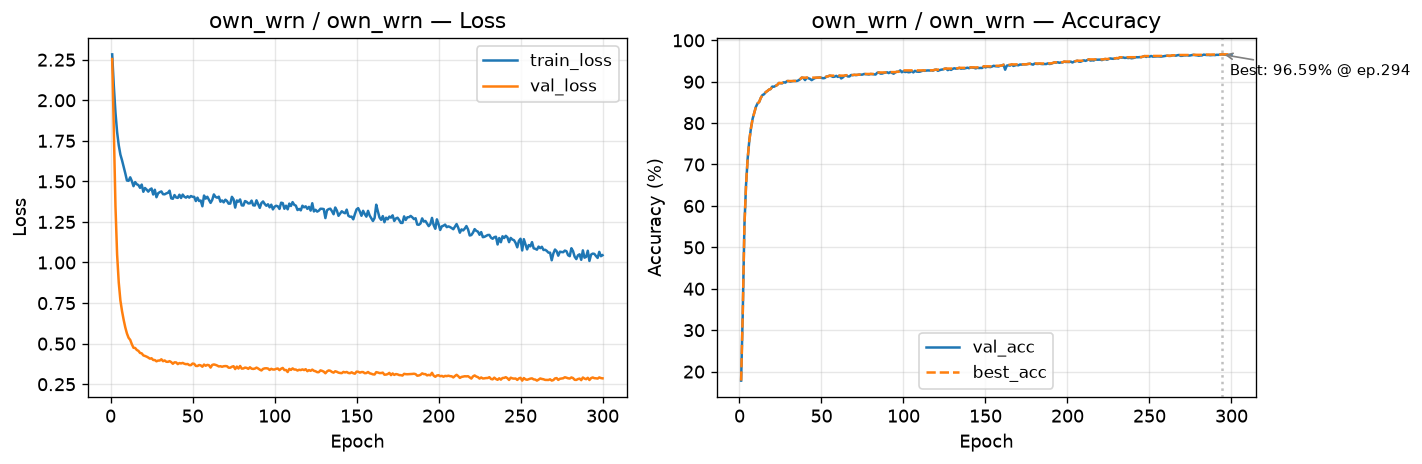

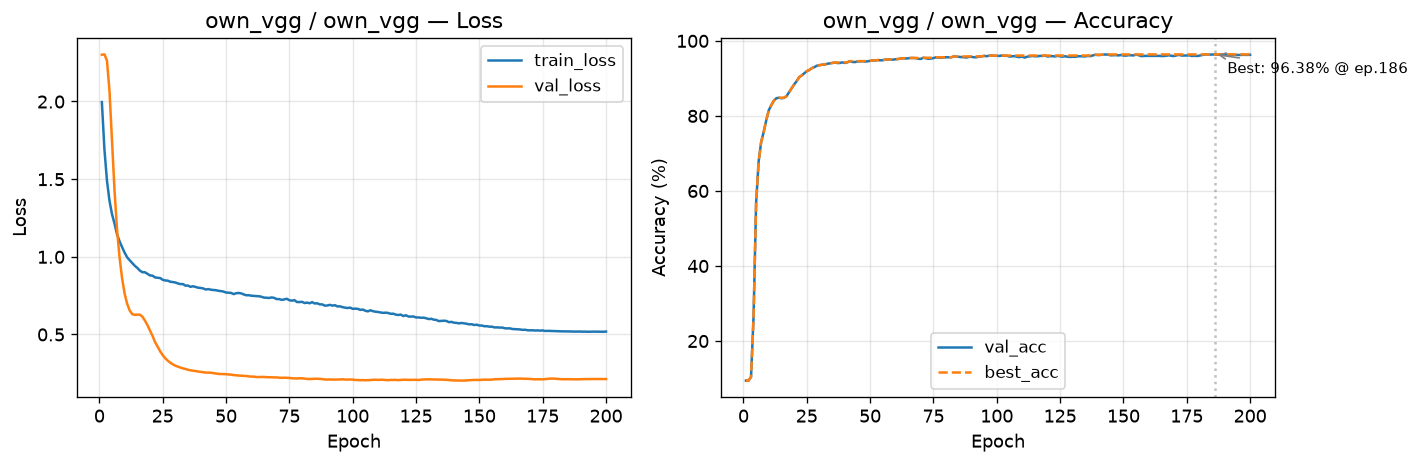

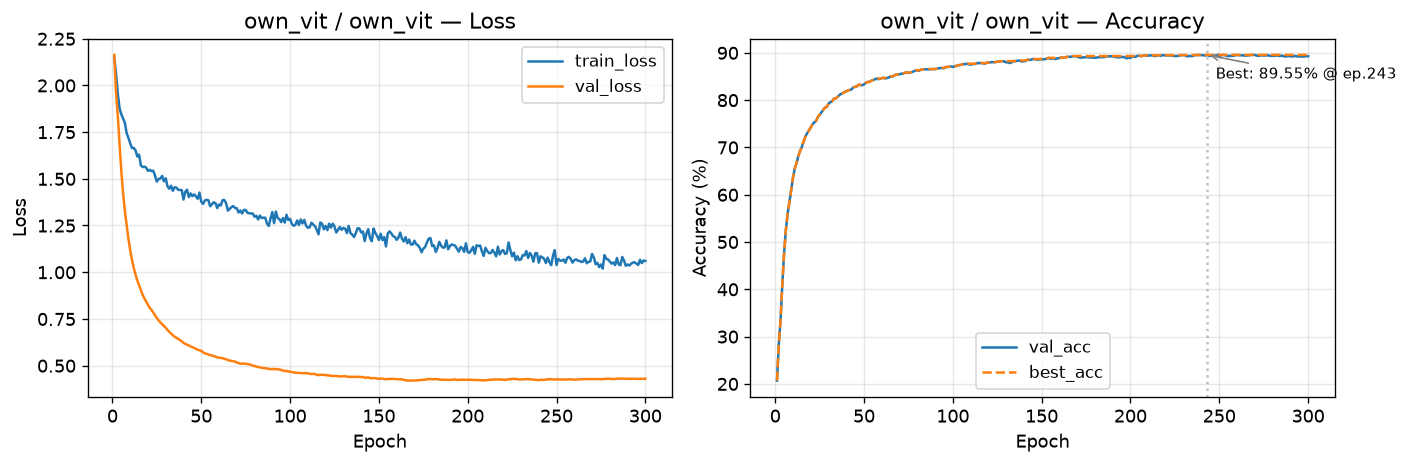

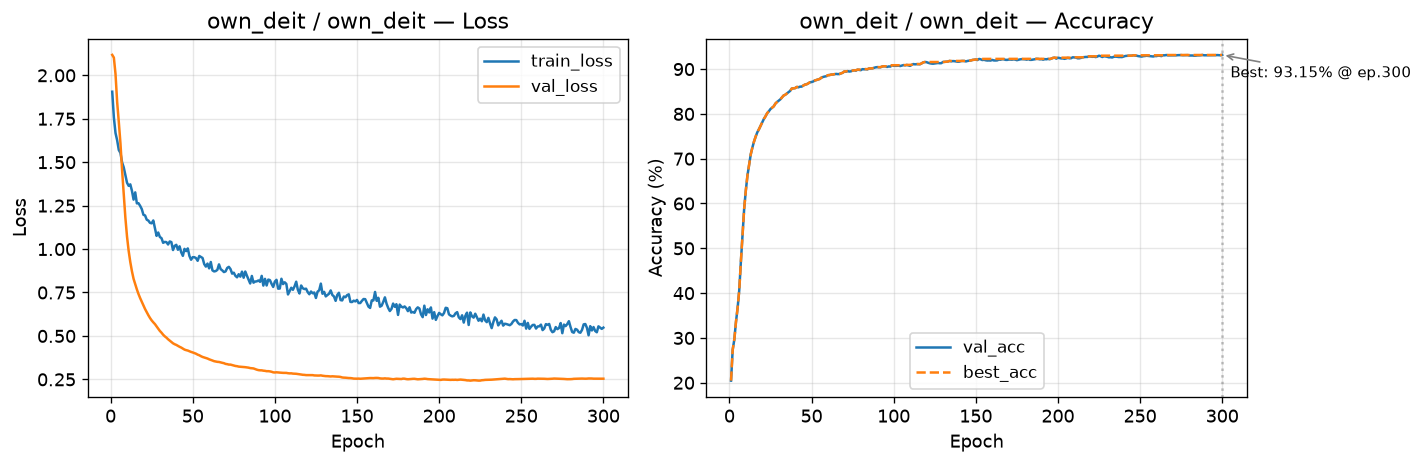

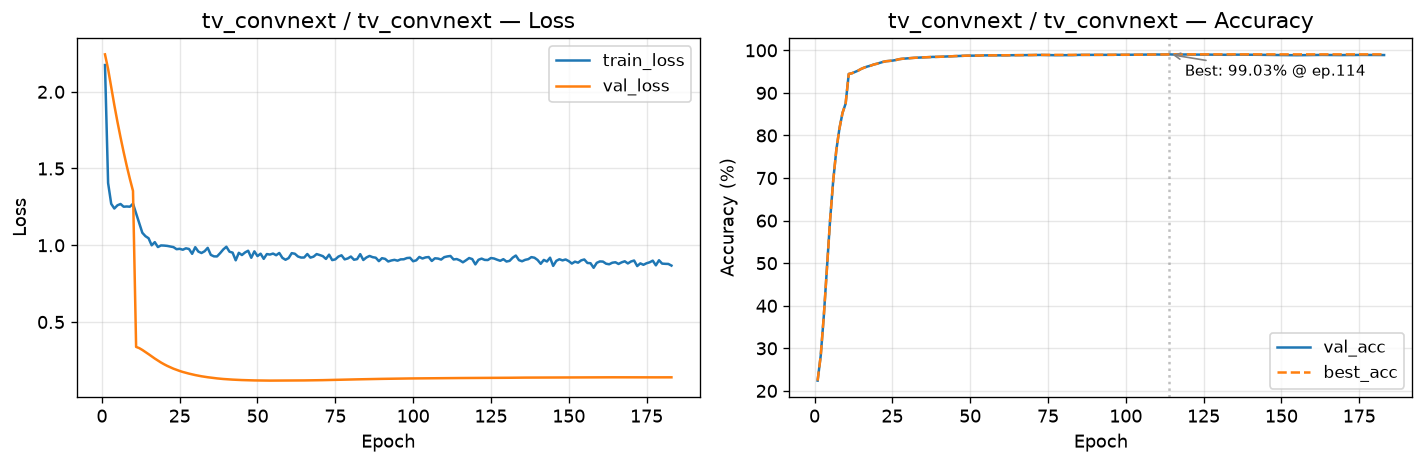

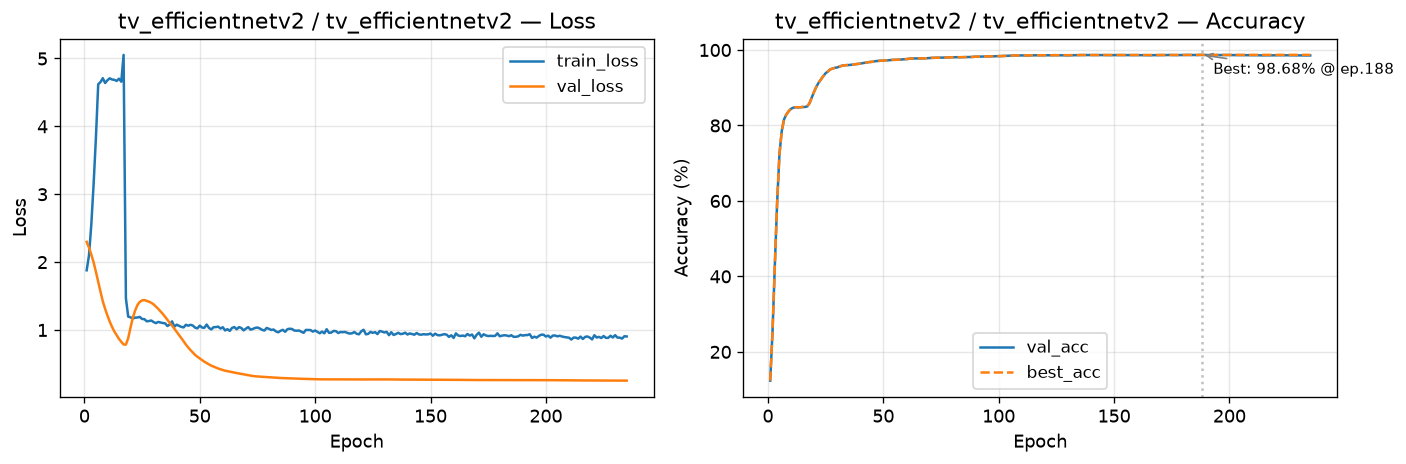

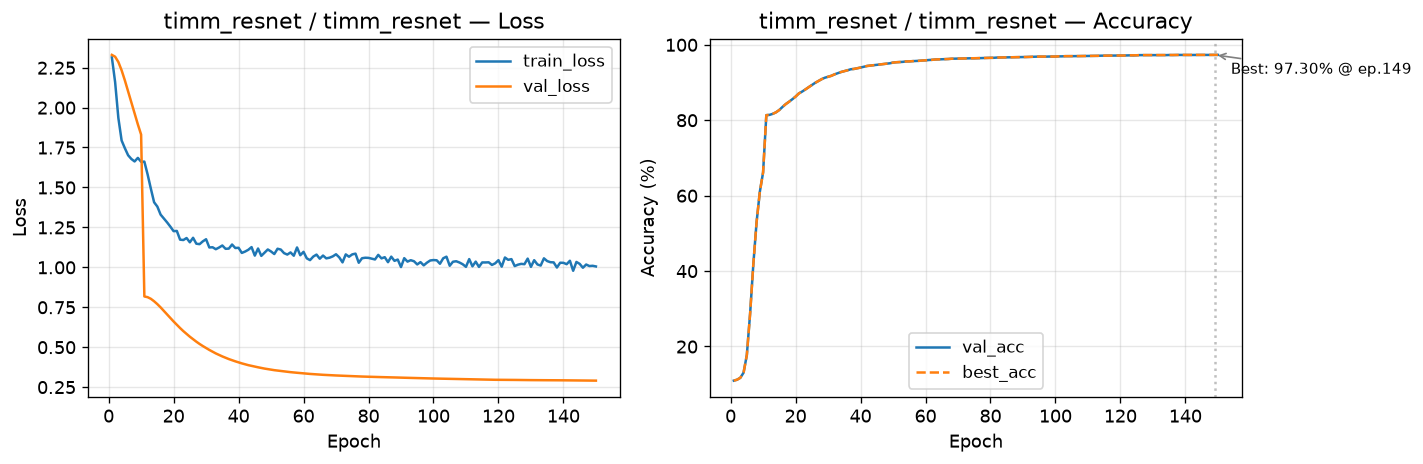

In [26]:
# ---------------------------------------------------------------------------
# Individual run plots (loss + accuracy)
# ---------------------------------------------------------------------------

def plot_run(df: pd.DataFrame, title: str, save_name: str = None):
    """Plot loss and accuracy for a single run."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    axes[0].plot(df["epoch"], df["train_loss"], label="train_loss", lw=1.5)
    axes[0].plot(df["epoch"], df["val_loss"], label="val_loss", lw=1.5)
    axes[0].set_title(f"{title} \u2014 Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # Accuracy
    best_epoch = df.loc[df["best_acc"].idxmax(), "epoch"]
    best_val = df["best_acc"].max()
    axes[1].plot(df["epoch"], df["val_acc"], label="val_acc", lw=1.5)
    axes[1].plot(df["epoch"], df["best_acc"], label="best_acc", lw=1.5, ls="--")
    axes[1].axvline(best_epoch, color="gray", ls=":", alpha=0.5)
    axes[1].annotate(
        f"Best: {best_val:.2f}% @ ep.{int(best_epoch)}",
        xy=(best_epoch, best_val),
        xytext=(best_epoch + 5, best_val - 5),
        fontsize=9,
        arrowprops=dict(arrowstyle="->", color="gray", lw=1),
    )
    axes[1].set_title(f"{title} \u2014 Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    if save_name:
        save_figure(fig, save_name)
    plt.show()


for model_name, runs in experiments.items():
    for run_name, df in runs.items():
        plot_run(df, f"{model_name} / {run_name}")

## Validation Accuracy — All Runs
  [saved] /Users/esteban/src/cifar10/docs/figures/val_acc_comparison.png


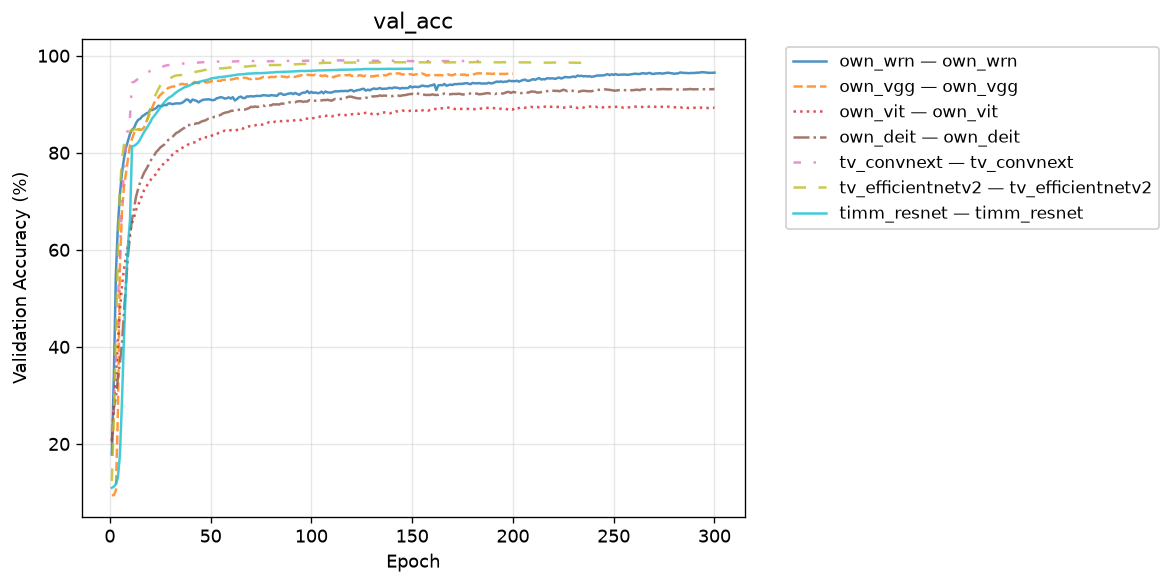

## Validation Loss — All Runs
  [saved] /Users/esteban/src/cifar10/docs/figures/val_loss_comparison.png


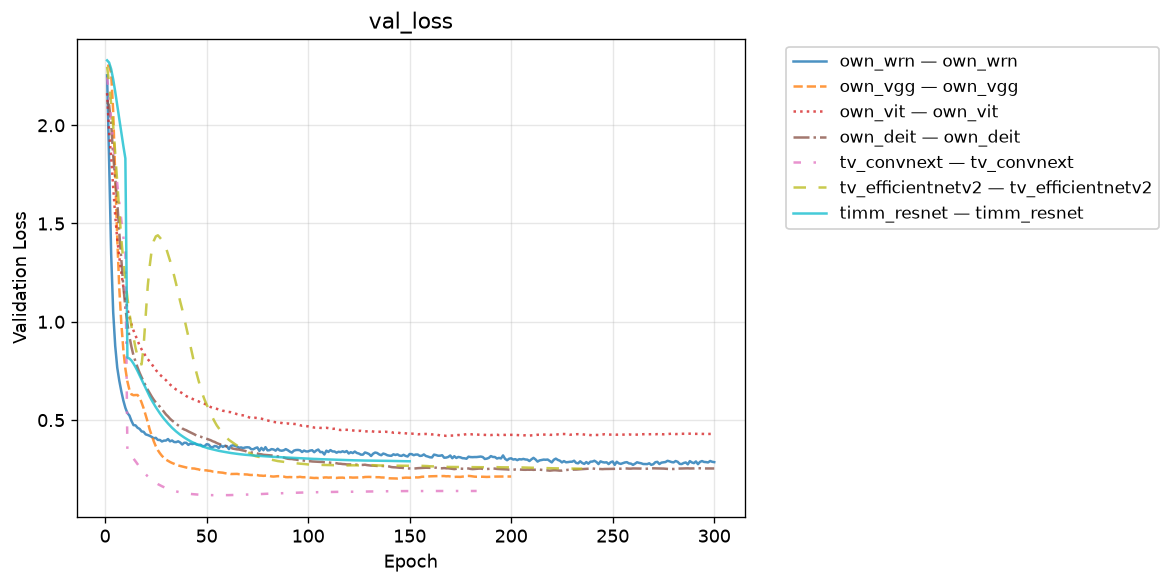

## Best Run per Architecture
  [saved] /Users/esteban/src/cifar10/docs/figures/best_accuracy.png


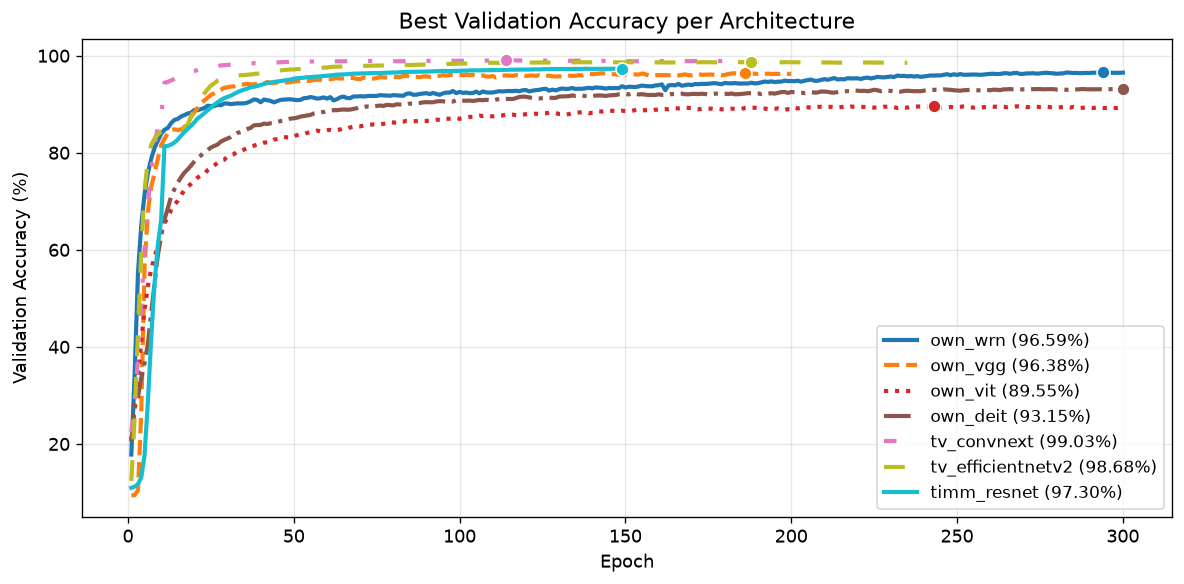

In [27]:
# ---------------------------------------------------------------------------
# Comparison plots (all runs overlaid per metric)
# ---------------------------------------------------------------------------

MODEL_COLORS = {}
MODEL_LINESTYLES = {}

# Build color/line style maps from experiments
all_labels = list(experiments.keys())
default_colors = plt.cm.tab10(np.linspace(0, 1, len(all_labels)))
default_ls = ['-', '--', ':', '-.', (0, (3, 5, 1, 5)), (0, (5, 5))]
for i, label in enumerate(all_labels):
    MODEL_COLORS[label] = default_colors[i]
    MODEL_LINESTYLES[label] = default_ls[i % len(default_ls)]


def plot_metric_comparison(experiments, metric: str, ylabel: str = None,
                           save_name: str = None):
    """Plot one metric for all runs, grouped by architecture."""
    fig, ax = plt.subplots()

    for model_name, runs in experiments.items():
        color = MODEL_COLORS.get(model_name, "gray")
        ls = MODEL_LINESTYLES.get(model_name, "-")
        for run_name, df in runs.items():
            label = f"{model_name} \u2014 {run_name}"
            ax.plot(df["epoch"], df[metric], label=label,
                    color=color, ls=ls, lw=1.5, alpha=0.8)

    ax.set_title(metric)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel or metric)
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", framealpha=0.9)
    plt.tight_layout()
    if save_name:
        save_figure(fig, save_name)
    plt.show()


def get_best_run(runs: dict[str, pd.DataFrame]):
    """Return (run_name, df, best_accuracy) for the best run."""
    best_name = None
    best_df = None
    best_acc = -1
    for run_name, df in runs.items():
        run_best = df["best_acc"].max()
        if run_best > best_acc:
            best_acc = run_best
            best_name = run_name
            best_df = df
    return best_name, best_df, best_acc


def plot_best_runs_comparison(experiments, save_name: str = None):
    """Compare only the best run of each architecture with accuracy marker."""
    fig, ax = plt.subplots()

    for model_name, runs in experiments.items():
        run_name, df, best_acc = get_best_run(runs)
        color = MODEL_COLORS.get(model_name, "gray")
        ls = MODEL_LINESTYLES.get(model_name, "-")
        ax.plot(df["epoch"], df["val_acc"],
                label=f"{model_name} ({best_acc:.2f}%)",
                color=color, ls=ls, lw=2.5)
        best_row = df.loc[df["best_acc"].idxmax()]
        ax.scatter([best_row["epoch"]], [best_row["best_acc"]],
                   color=color, s=60, zorder=5,
                   edgecolors="white", linewidths=1)

    ax.set_title("Best Validation Accuracy per Architecture")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Accuracy (%)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    if save_name:
        save_figure(fig, save_name)
    plt.show()


# --- Generate comparison plots & save ---
print("## Validation Accuracy \u2014 All Runs")
plot_metric_comparison(experiments, "val_acc",
                       ylabel="Validation Accuracy (%)",
                       save_name="val_acc_comparison.png")

print("## Validation Loss \u2014 All Runs")
plot_metric_comparison(experiments, "val_loss",
                       ylabel="Validation Loss",
                       save_name="val_loss_comparison.png")

print("## Best Run per Architecture")
plot_best_runs_comparison(experiments, save_name="best_accuracy.png")

## Learning Rate Schedules
  [saved] /Users/esteban/src/cifar10/docs/figures/lr_schedules.png


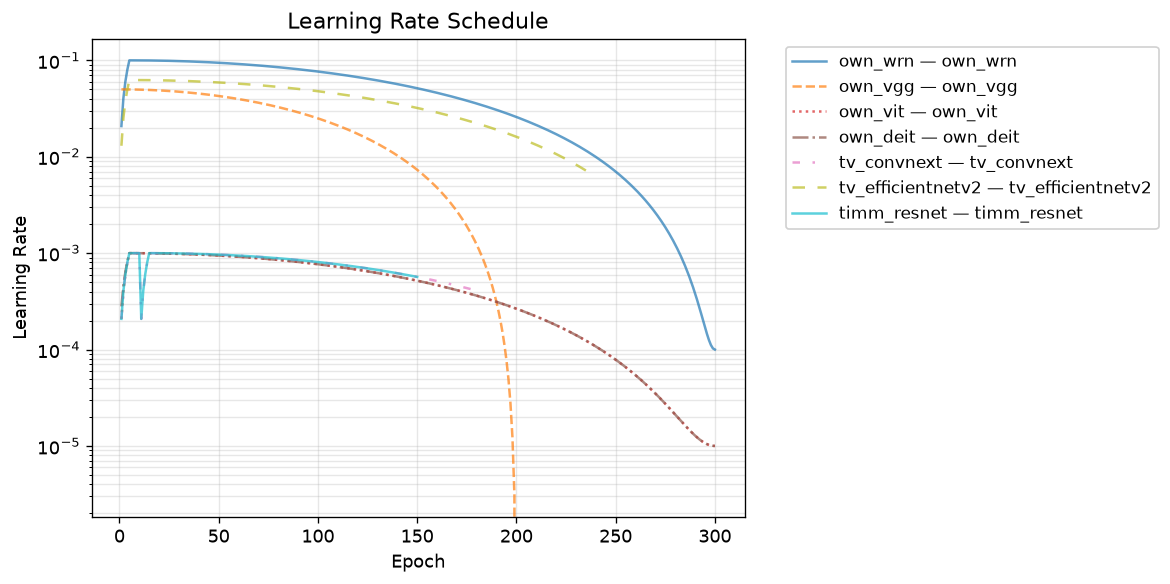

In [28]:
# ---------------------------------------------------------------------------
# Learning Rate Schedule
# ---------------------------------------------------------------------------

def plot_lr_schedules(experiments, save_name: str = None):
    """Plot LR schedules for all runs."""
    fig, ax = plt.subplots()

    for model_name, runs in experiments.items():
        color = MODEL_COLORS.get(model_name, "gray")
        ls = MODEL_LINESTYLES.get(model_name, "-")
        for run_name, df in runs.items():
            lr_series = df["lr"].clip(lower=0)
            ax.plot(df["epoch"], lr_series,
                    label=f"{model_name} \u2014 {run_name}",
                    color=color, ls=ls, lw=1.5, alpha=0.7)

    ax.set_title("Learning Rate Schedule")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Learning Rate")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3, which="both")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", framealpha=0.9)
    plt.tight_layout()
    if save_name:
        save_figure(fig, save_name)
    plt.show()


print("## Learning Rate Schedules")
plot_lr_schedules(experiments, save_name="lr_schedules.png")

## Convergence Speed Comparison
  [saved] /Users/esteban/src/cifar10/docs/figures/convergence.png


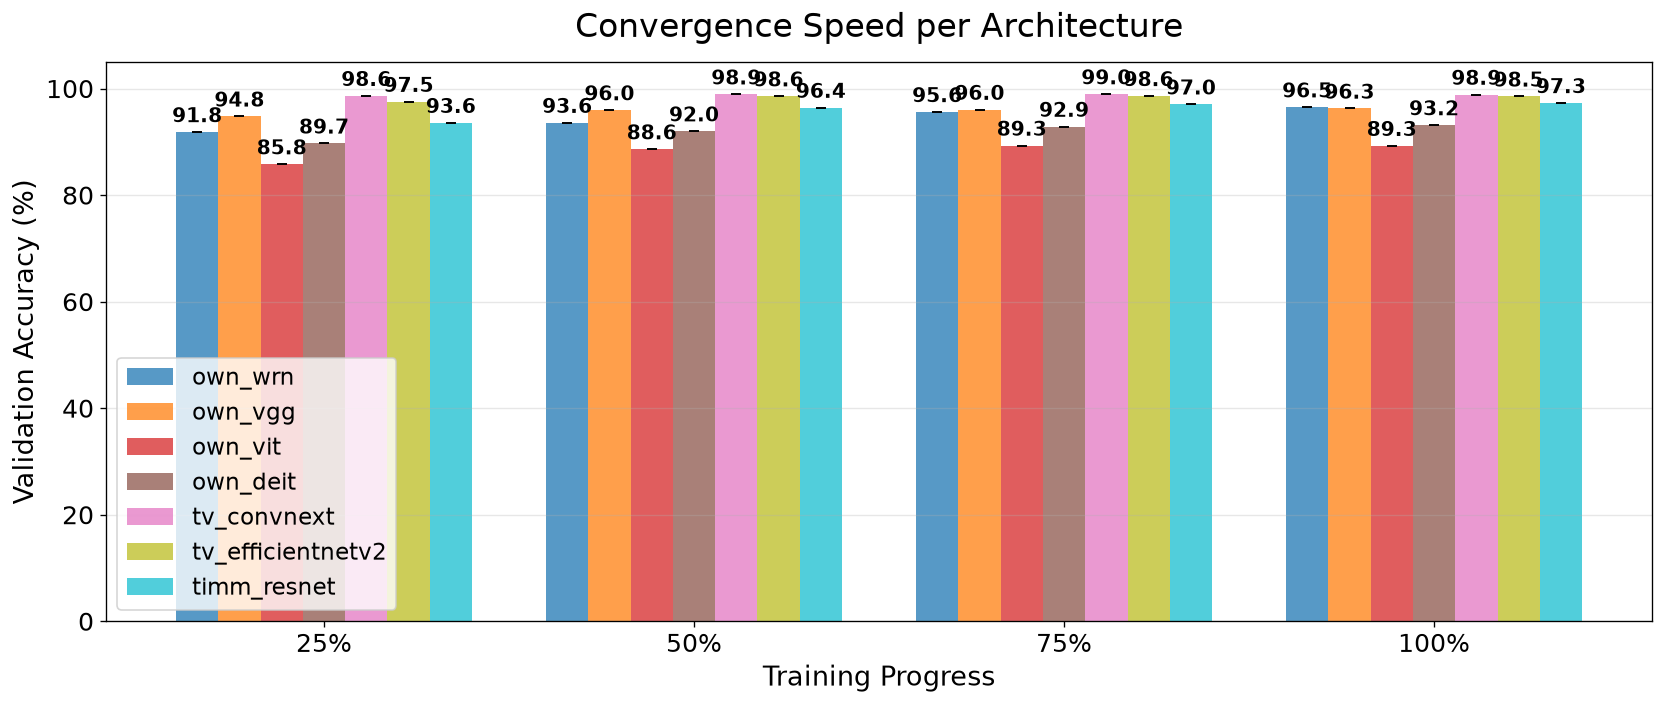

In [29]:
# ---------------------------------------------------------------------------
# Convergence Speed: Accuracy at 25%, 50%, 75%, 100% of training
# ---------------------------------------------------------------------------

def plot_convergence_summary(experiments, save_name: str = None):
    """
    Bar chart showing validation accuracy at 25%, 50%, 75%, 100% epochs.
    """
    checkpoints_pct = [0.25, 0.50, 0.75, 1.0]
    data = {label: [] for label in experiments}

    for label, runs in experiments.items():
        for _, df in runs.items():
            total = len(df)
            for pct in checkpoints_pct:
                idx = min(int(total * pct), total - 1)
                data[label].append(df.iloc[idx]["val_acc"])

    n_models = len(experiments)
    x = np.arange(len(checkpoints_pct))
    width = 0.8 / n_models

    fig, ax = plt.subplots(figsize=(14, 6))

    max_val = 0

    for i, (label, values_list) in enumerate(data.items()):
        color = MODEL_COLORS.get(label, "gray")

        arr = np.array(values_list).reshape(-1, len(checkpoints_pct))
        means = arr.mean(axis=0)
        stds = arr.std(axis=0)

        max_val = max(max_val, np.max(means + stds))

        offset = (i - n_models / 2 + 0.5) * width

        bars = ax.bar(
            x + offset,
            means,
            width,
            label=label,
            color=color,
            alpha=0.75,
            yerr=stds,
            capsize=3,
        )
        
        ax.bar_label(
            bars,
            labels=[f"{v:.1f}" for v in means],
            padding=3,
            fontsize=12,
            fontweight="bold",
        )

    ax.set_ylim(0, max(105, max_val + 3))

    ax.set_title("Convergence Speed per Architecture", fontsize=20, pad=15)
    ax.set_xlabel("Training Progress", fontsize=16)
    ax.set_ylabel("Validation Accuracy (%)", fontsize=16)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{int(p * 100)}%" for p in checkpoints_pct],
        fontsize=15,
    )

    ax.tick_params(axis="both", labelsize=15)

    ax.grid(True, axis="y", alpha=0.3)

    ax.legend(
        fontsize=14,
        title_fontsize=15,
        loc="lower left",
    )

    plt.tight_layout()

    if save_name:
        save_figure(fig, save_name)

    plt.show()

print("## Convergence Speed Comparison")
plot_convergence_summary(experiments, save_name="convergence.png")

## Dashboard
  [saved] /Users/esteban/src/cifar10/docs/figures/dashboard.png


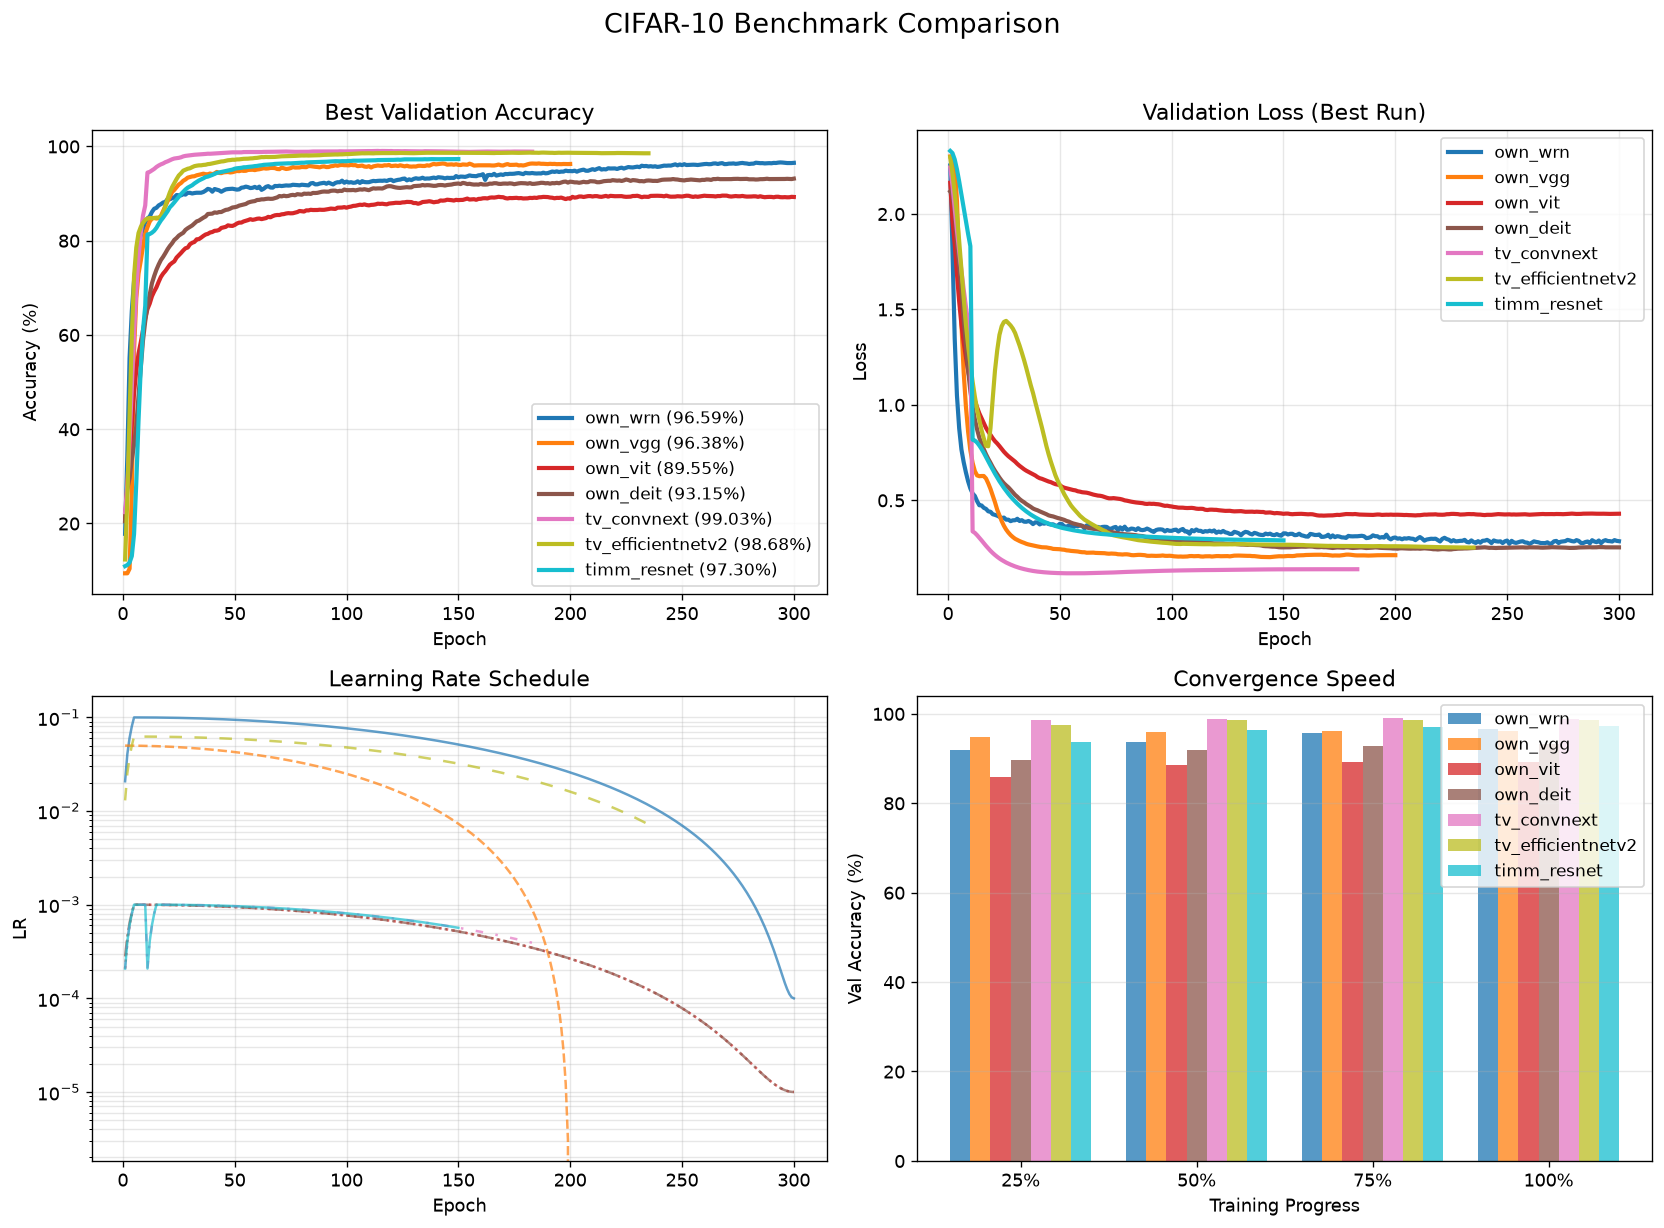

In [30]:
# ---------------------------------------------------------------------------
# All-in-one dashboard figure for reports
# ---------------------------------------------------------------------------

def plot_dashboard(experiments, save_name: str = None):
    """Create a 2x2 dashboard figure for reports."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Top-left: best run val_acc
    ax = axes[0, 0]
    for model_name, runs in experiments.items():
        _, df, best_acc = get_best_run(runs)
        color = MODEL_COLORS.get(model_name, "gray")
        ax.plot(df["epoch"], df["val_acc"],
                label=f"{model_name} ({best_acc:.2f}%)",
                color=color, lw=2.5)
    ax.set_title("Best Validation Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy (%)")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Top-right: best run val_loss
    ax = axes[0, 1]
    for model_name, runs in experiments.items():
        _, df, _ = get_best_run(runs)
        color = MODEL_COLORS.get(model_name, "gray")
        ax.plot(df["epoch"], df["val_loss"],
                label=model_name, color=color, lw=2.5)
    ax.set_title("Validation Loss (Best Run)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Bottom-left: LR schedules
    ax = axes[1, 0]
    for model_name, runs in experiments.items():
        color = MODEL_COLORS.get(model_name, "gray")
        ls = MODEL_LINESTYLES.get(model_name, "-")
        for run_name, df in runs.items():
            ax.plot(df["epoch"], df["lr"].clip(lower=0),
                    label=model_name if run_name == list(runs.keys())[0] else "",
                    color=color, ls=ls, lw=1.5, alpha=0.7)
    ax.set_title("Learning Rate Schedule")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("LR")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3, which="both")

    # Bottom-right: convergence bar chart
    ax = axes[1, 1]
    checkpoints_pct = [0.25, 0.50, 0.75, 1.0]
    n_models = len(experiments)
    x = np.arange(len(checkpoints_pct))
    width = 0.8 / n_models
    for i, (label, runs) in enumerate(experiments.items()):
        color = MODEL_COLORS.get(label, "gray")
        vals = []
        for run_name, df in runs.items():
            total = len(df)
            row = []
            for pct in checkpoints_pct:
                idx = min(int(total * pct), total - 1)
                row.append(df.iloc[idx]["val_acc"])
            vals.append(row)
        arr = np.array(vals)
        means = arr.mean(axis=0)
        stds = arr.std(axis=0) if arr.shape[0] > 1 else np.zeros_like(means)
        offset = (i - n_models / 2 + 0.5) * width
        ax.bar(x + offset, means, width, label=label,
               color=color, alpha=0.75,
               yerr=stds if stds.sum() > 0 else None, capsize=3)
    ax.set_title("Convergence Speed")
    ax.set_xlabel("Training Progress")
    ax.set_ylabel("Val Accuracy (%)")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(p * 100)}%" for p in checkpoints_pct])
    ax.grid(True, alpha=0.3, axis="y")
    ax.legend()

    plt.suptitle("CIFAR-10 Benchmark Comparison", fontsize=16, y=1.02)
    plt.tight_layout()
    if save_name:
        save_figure(fig, save_name)
    plt.show()


print("## Dashboard")
plot_dashboard(experiments, save_name="dashboard.png")

In [31]:
# ---------------------------------------------------------------------------
# Cross-architecture summary
# ---------------------------------------------------------------------------

print("## Cross-Architecture Summary\n")

for label, runs in experiments.items():
    meta = metadata.get(label, {})
    all_best = [df["best_acc"].max() for df in runs.values()]
    all_final = [df.iloc[-1]["val_acc"] for df in runs.values()]

    run_name, best_df, best_acc_val = get_best_run(runs)
    best_epoch = int(best_df.loc[best_df["best_acc"].idxmax(), "epoch"])

    n_runs = len(runs)
    mean_best = np.mean(all_best)
    std_best = np.std(all_best) if n_runs > 1 else 0
    mean_final = np.mean(all_final)
    std_final = np.std(all_final) if n_runs > 1 else 0

    param_m = meta.get("param_count_m", None)
    input_size = meta.get("input_size", 32)
    pretrained = meta.get("pretrained", "No (scratch)")
    source = meta.get("source", "own")
    source_map = {"own": "Own", "tv": "TorchVision", "timm": "TIMM"}
    source_label = source_map.get(source, source)
    params_str = f"{param_m:.2f}M" if param_m is not None else "N/A"

    print(f"**{label}** ({source_label})  ")
    print(f"- Runs: {n_runs}  ")
    print(f"- Parameters: {params_str}  ")
    print(f"- Input Size: {input_size}\u00d7{input_size}  ")
    print(f"- Pretrained: {pretrained}  ")
    print(f"- Best Acc: {mean_best:.2f}% \u00b1 {std_best:.2f}%  ")
    if n_runs > 1:
        print(f"  (range: {min(all_best):.2f}% \u2014 {max(all_best):.2f}%)  ")
    print(f"- Best Epoch: {best_epoch}  ")
    print(f"- Final Val Acc: {mean_final:.2f}% \u00b1 {std_final:.2f}%  ")
    print()

# Winner
if not results_df.empty:
    best_overall_label = results_df.iloc[0]["Architecture"]
    best_overall_acc = results_df.iloc[0]["Best Acc (%)"]
    print("---\n")
    print(f"**Best overall:** {best_overall_label} with {best_overall_acc:.2f}%")

## Cross-Architecture Summary

**own_wrn** (Own)  
- Runs: 1  
- Parameters: 2.75M  
- Input Size: 32×32  
- Pretrained: No (scratch)  
- Best Acc: 96.59% ± 0.00%  
- Best Epoch: 294  
- Final Val Acc: 96.50% ± 0.00%  

**own_vgg** (Own)  
- Runs: 1  
- Parameters: 19.18M  
- Input Size: 32×32  
- Pretrained: No (scratch)  
- Best Acc: 96.38% ± 0.00%  
- Best Epoch: 186  
- Final Val Acc: 96.26% ± 0.00%  

**own_vit** (Own)  
- Runs: 1  
- Parameters: 2.69M  
- Input Size: 32×32  
- Pretrained: No (scratch)  
- Best Acc: 89.55% ± 0.00%  
- Best Epoch: 243  
- Final Val Acc: 89.26% ± 0.00%  

**own_deit** (Own)  
- Runs: 1  
- Parameters: 2.86M  
- Input Size: 32×32  
- Pretrained: No (scratch)  
- Best Acc: 93.15% ± 0.00%  
- Best Epoch: 300  
- Final Val Acc: 93.15% ± 0.00%  

**tv_convnext** (TorchVision)  
- Runs: 1  
- Parameters: 27.83M  
- Input Size: 128×128  
- Pretrained: No (scratch)  
- Best Acc: 99.03% ± 0.00%  
- Best Epoch: 114  
- Final Val Acc: 98.87% ± 0.00%  

**tv_ef